In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [8]:
# 1. LOAD EXCEL FILE

FILE_PATH = "eda1.xlsx"

apps = pd.read_csv(r"C:\Users\hsami\OneDrive\Desktop\EDA1_GOOGLE_PLAY_STORE\googleplaystore.csv")
reviews = pd.read_csv(r"C:\Users\hsami\OneDrive\Desktop\EDA1_GOOGLE_PLAY_STORE\googleplaystore_user_reviews.csv")

print("=" * 70)
print("✅ FILES LOADED SUCCESSFULLY")
print("=" * 70)
print(f"Apps dataset   → Shape: {apps.shape}")
print(f"Reviews dataset → Shape: {reviews.shape}")
print(f"\nApps columns   : {apps.columns.tolist()}")
print(f"Reviews columns: {reviews.columns.tolist()}")

# 2. DATA PREVIEW

print("\n" + "=" * 70)
print("📌 APPS DATA (First 5 rows)")
print("=" * 70)
print(apps.head())

print("\n" + "=" * 70)
print("📌 REVIEWS DATA (First 5 rows)")
print("=" * 70)
print(reviews.head())

# 3.DATA INFO & MISSING VALUES

print("\n" + "=" * 70)
print("📌 APPS DATA INFO")
print("=" * 70)
print(apps.info())
print("\nMissing values in Apps:\n", apps.isnull().sum())

print("\n" + "=" * 70)
print("📌 REVIEWS DATA INFO")
print("=" * 70)
print(reviews.info())
print("\nMissing values in Reviews:\n", reviews.isnull().sum())

# 4. DATA CLEANING

print("\n" + "=" * 70)
print("🧹 CLEANING DATA")
print("=" * 70)

# Fix shifted rows 
apps = apps[apps["Category"].notna()].copy()

# Clean Installs column 
apps["Installs_clean"] = (
    apps["Installs"].astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)
apps["Installs_clean"] = pd.to_numeric(apps["Installs_clean"], errors="coerce")

# Clean Size column 
def clean_size(x):
    if pd.isna(x) or str(x) == "Varies with device":
        return np.nan
    x = str(x).strip()
    try:
        if x.endswith("M"):
            return float(x[:-1]) * 1_000_000
        elif x.endswith("k"):
            return float(x[:-1]) * 1_000
        elif x.endswith("G"):
            return float(x[:-1]) * 1_000_000_000
        else:
            return float(x)
    except ValueError:
        return np.nan

apps["Size_bytes"] = apps["Size"].apply(clean_size)

# Clean Reviews column 
apps["Reviews"] = pd.to_numeric(apps["Reviews"], errors="coerce")

# Clean Price column 
apps["Price_clean"] = (
    apps["Price"].astype(str)
    .str.replace("$", "", regex=False)
)
apps["Price_clean"] = pd.to_numeric(apps["Price_clean"], errors="coerce")

# Drop NaN reviews in Sheet2
reviews_clean = reviews.dropna(subset=["Translated_Review"]).copy()
print(f"Reviews after dropping NaN: {reviews_clean.shape}")

print("✅ Cleaning complete.")

# 5. DESCRIPTIVE STATISTICS

print("\n" + "=" * 70)
print("📊 STATISTICAL SUMMARY - APPS")
print("=" * 70)
print(apps[["Rating", "Reviews", "Installs_clean", "Price_clean"]].describe())

print("\n" + "=" * 70)
print("📊 STATISTICAL SUMMARY - REVIEWS")
print("=" * 70)
print(reviews_clean[["Sentiment_Polarity", "Sentiment_Subjectivity"]].describe())


✅ FILES LOADED SUCCESSFULLY
Apps dataset   → Shape: (10841, 13)
Reviews dataset → Shape: (64295, 5)

Apps columns   : ['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']
Reviews columns: ['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity', 'Sentiment_Subjectivity']

📌 APPS DATA (First 5 rows)
                                                 App        Category  Rating  \
0     Photo Editor & Candy Camera & Grid & ScrapBook  ART_AND_DESIGN     4.1   
1                                Coloring book moana  ART_AND_DESIGN     3.9   
2  U Launcher Lite – FREE Live Cool Themes, Hide ...  ART_AND_DESIGN     4.7   
3                              Sketch - Draw & Paint  ART_AND_DESIGN     4.5   
4              Pixel Draw - Number Art Coloring Book  ART_AND_DESIGN     4.3   

  Reviews  Size     Installs  Type Price Content Rating  \
0     159   19M      10,000+  Free     0       Everyone

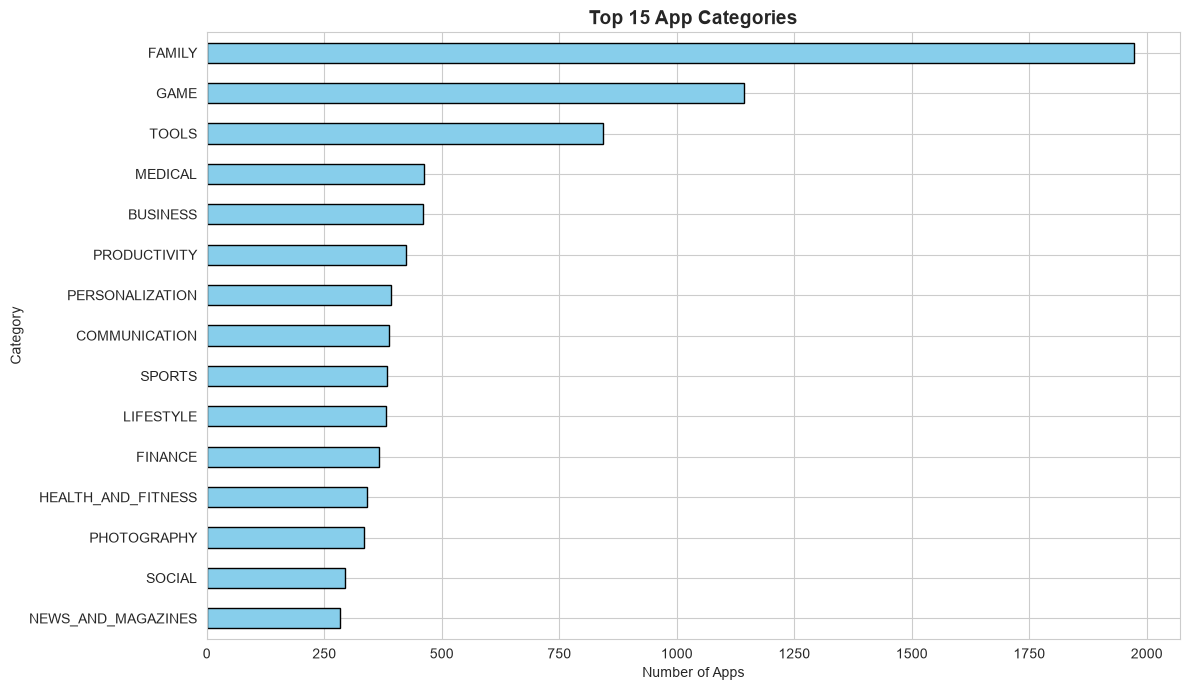

In [9]:
 # VISUALIZATIONS

# 1.Top 15 Categories

plt.figure(figsize=(12, 7))
apps["Category"].value_counts().head(15).plot(kind="barh", color="skyblue", edgecolor="black")
plt.title("Top 15 App Categories", fontsize=14, fontweight="bold")
plt.xlabel("Number of Apps")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

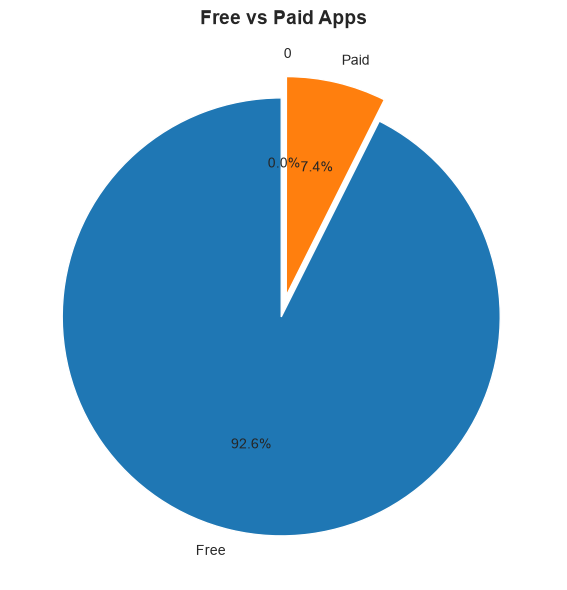

In [ ]:
# 2 Free vs Paid Apps 

type_counts = apps["Type"].value_counts()
plt.figure(figsize=(6, 6))

type_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    explode=[0.05] * len(type_counts)
)

plt.title("Free vs Paid Apps", fontsize=14, fontweight="bold")
plt.ylabel("")
plt.tight_layout()
plt.show()

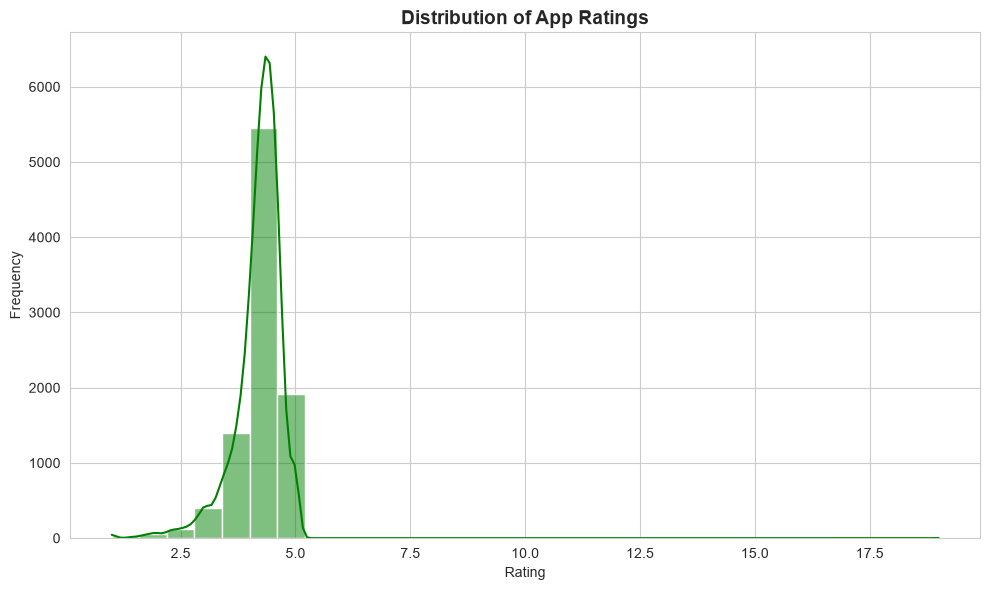

In [14]:
# 3. Rating Distribution 

plt.figure(figsize=(10, 6))
sns.histplot(apps["Rating"].dropna(), bins=30, kde=True, color="green")
plt.title("Distribution of App Ratings", fontsize=14, fontweight="bold")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


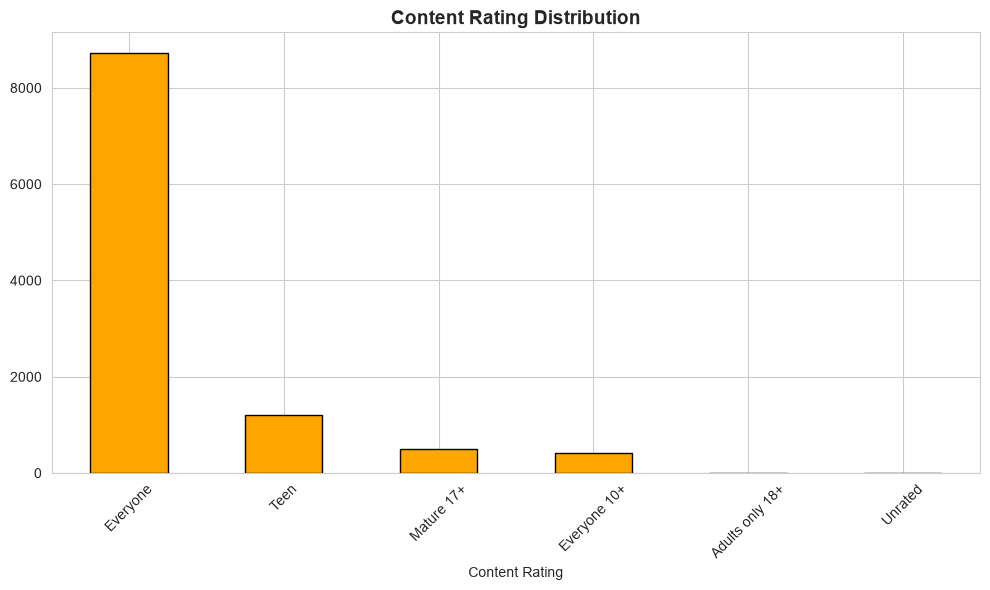

In [13]:
# 4. Content Rating Distribution 

plt.figure(figsize=(10, 6))
apps["Content Rating"].value_counts().plot(kind="bar", color="orange", edgecolor="black")
plt.title("Content Rating Distribution", fontsize=14, fontweight="bold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

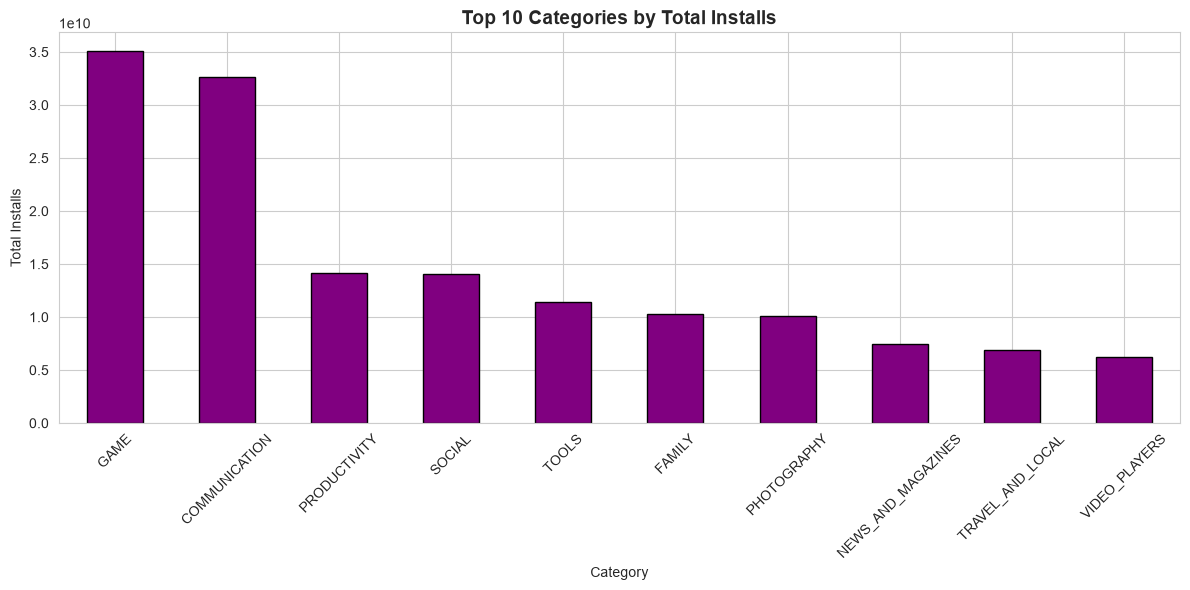

In [15]:
# 5. Top 10 Categories by Total Installs 

top_installs = (
    apps.groupby("Category")["Installs_clean"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(12, 6))
top_installs.plot(kind="bar", color="purple", edgecolor="black")
plt.title("Top 10 Categories by Total Installs", fontsize=14, fontweight="bold")
plt.ylabel("Total Installs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

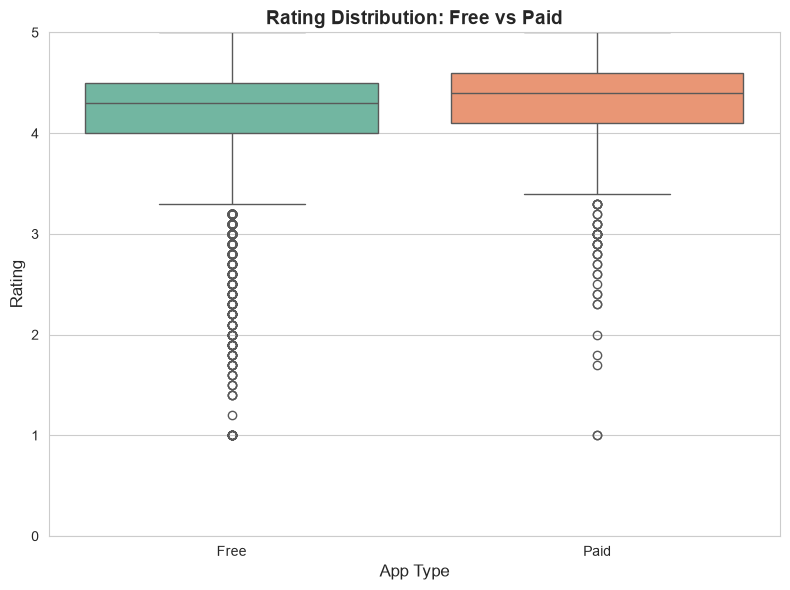

In [17]:
# 6. Boxplot of Ratings by Type


# Convert Rating to numeric
apps["Rating"] = pd.to_numeric(apps["Rating"], errors="coerce")

# Remove missing and invalid ratings
rating_data = apps[
    (apps["Rating"].notna()) &
    (apps["Rating"] >= 0) &
    (apps["Rating"] <= 5)
].copy()

# Create boxplot
plt.figure(figsize=(8, 6))

sns.boxplot(
    x="Type",
    y="Rating",
    data=rating_data,
    hue="Type",
    palette="Set2",
    legend=False
)

plt.title(
    "Rating Distribution: Free vs Paid",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("App Type", fontsize=12)
plt.ylabel("Rating", fontsize=12)

plt.ylim(0, 5)
plt.tight_layout()
plt.show()

In [18]:
# SENTIMENT ANALYSIS (SHEET 2)

print("\n" + "=" * 70)
print("💬 SENTIMENT ANALYSIS")
print("=" * 70)
print(reviews_clean["Sentiment"].value_counts())


💬 SENTIMENT ANALYSIS
Sentiment
Positive    23998
Negative     8271
Neutral      5158
Name: count, dtype: int64


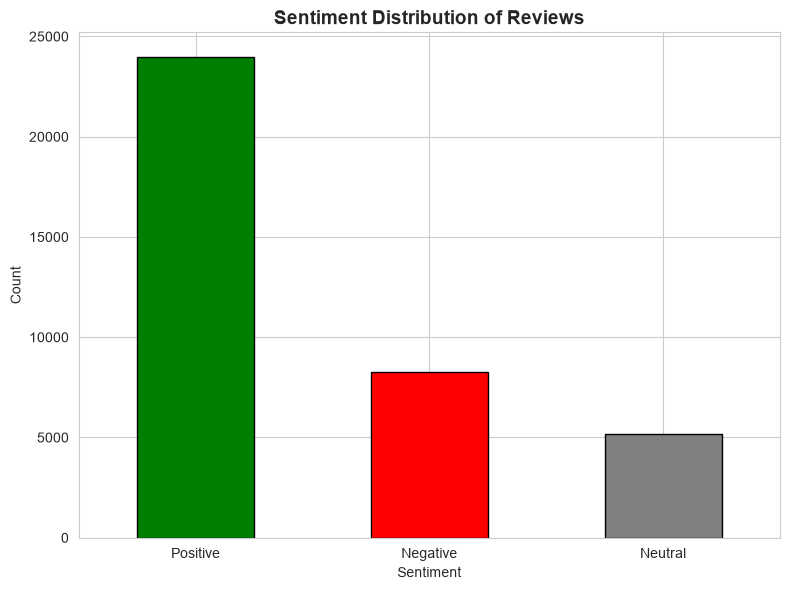

In [19]:
# 1. Sentiment Distribution

plt.figure(figsize=(8, 6))
reviews_clean["Sentiment"].value_counts().plot(
    kind="bar", color=["green", "red", "gray"], edgecolor="black"
)
plt.title("Sentiment Distribution of Reviews", fontsize=14, fontweight="bold")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


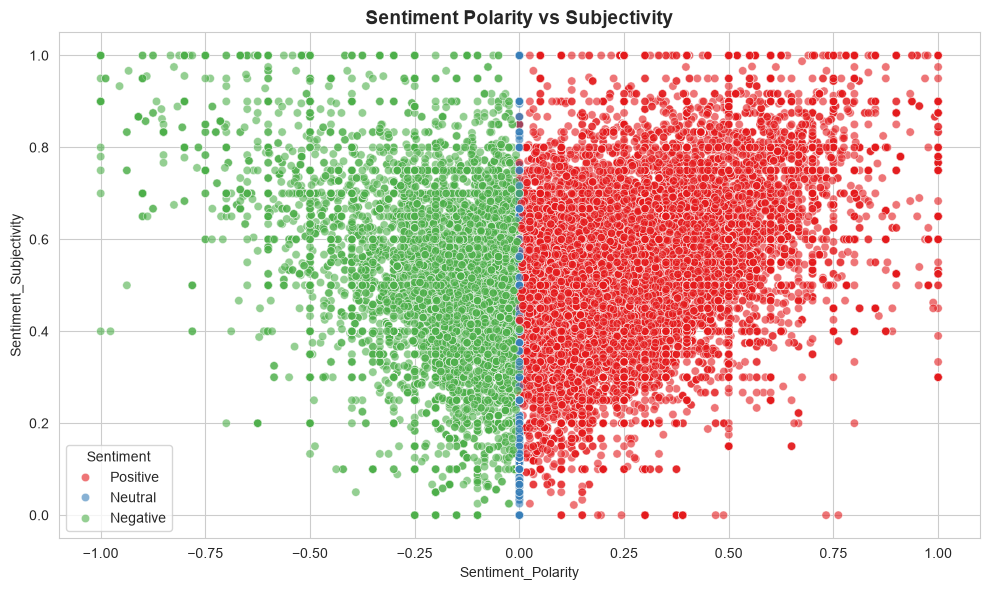

In [22]:
#2. Polarity vs Subjectivity 

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x="Sentiment_Polarity",
    y="Sentiment_Subjectivity",
    hue="Sentiment",
    data=reviews_clean,
    alpha=0.6, palette="Set1"
)
plt.title("Sentiment Polarity vs Subjectivity", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()



Top 10 Most Reviewed Apps:
 App
Bowmasters                        312
Angry Birds Classic               273
Helix Jump                        273
Calorie Counter - MyFitnessPal    254
Candy Crush Saga                  240
Duolingo: Learn Languages Free    240
Garena Free Fire                  222
8 Ball Pool                       219
Calorie Counter - Macros          200
10 Best Foods for You             194
Name: count, dtype: int64


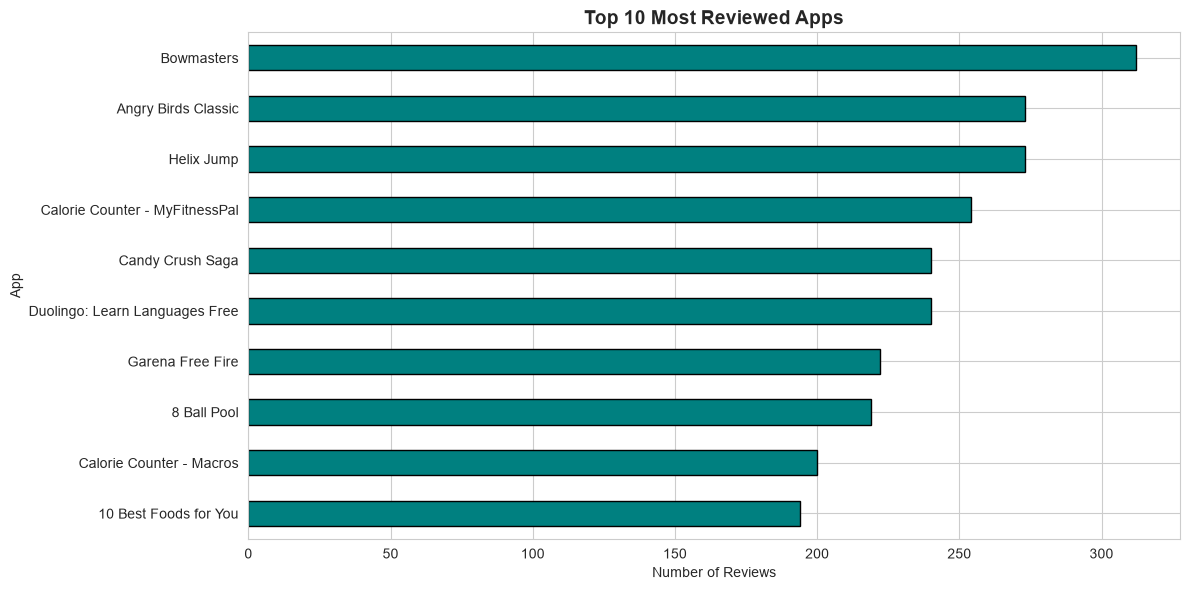

In [23]:
# 3. Top 10 Most Reviewed Apps 

top_reviewed = reviews_clean["App"].value_counts().head(10)
print("\nTop 10 Most Reviewed Apps:\n", top_reviewed)

plt.figure(figsize=(12, 6))
top_reviewed.plot(kind="barh", color="teal", edgecolor="black")
plt.title("Top 10 Most Reviewed Apps", fontsize=14, fontweight="bold")
plt.xlabel("Number of Reviews")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [24]:
# MERGE APPS + REVIEWS

merged = pd.merge(reviews_clean, apps, on="App", how="inner")
print("\n" + "=" * 70)
print(f"🔗 MERGED DATASET SHAPE: {merged.shape}")
print("=" * 70)


🔗 MERGED DATASET SHAPE: (72605, 20)


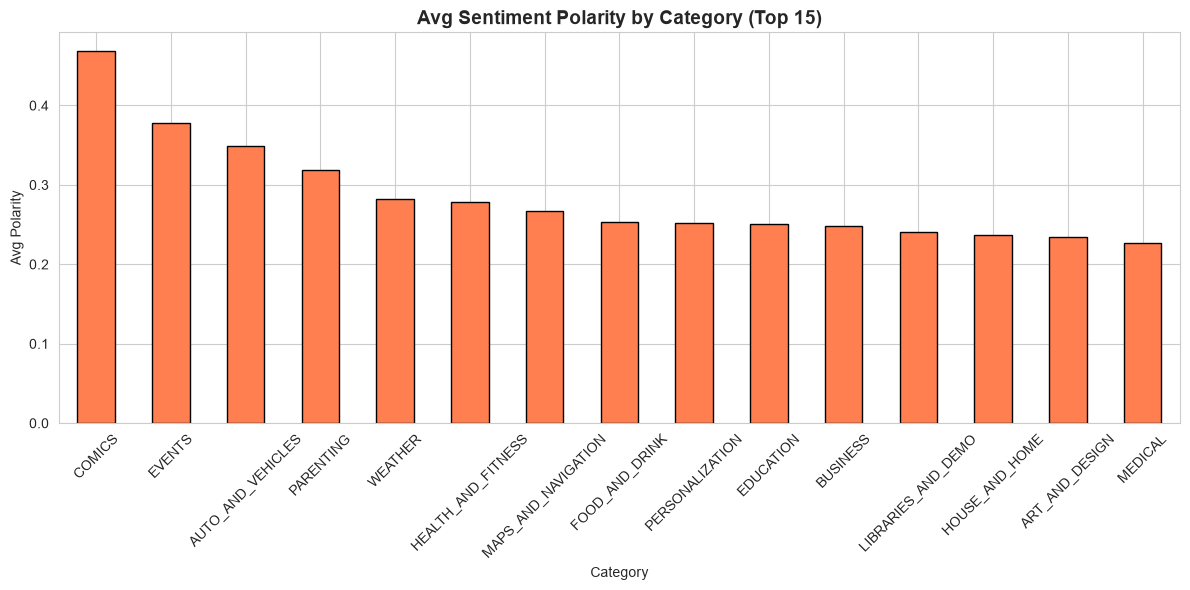

In [25]:
# 1. Average Sentiment Polarity by Category 

cat_sentiment = (
    merged.groupby("Category")["Sentiment_Polarity"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)
plt.figure(figsize=(12, 6))
cat_sentiment.plot(kind="bar", color="coral", edgecolor="black")
plt.title("Avg Sentiment Polarity by Category (Top 15)", fontsize=14, fontweight="bold")
plt.ylabel("Avg Polarity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

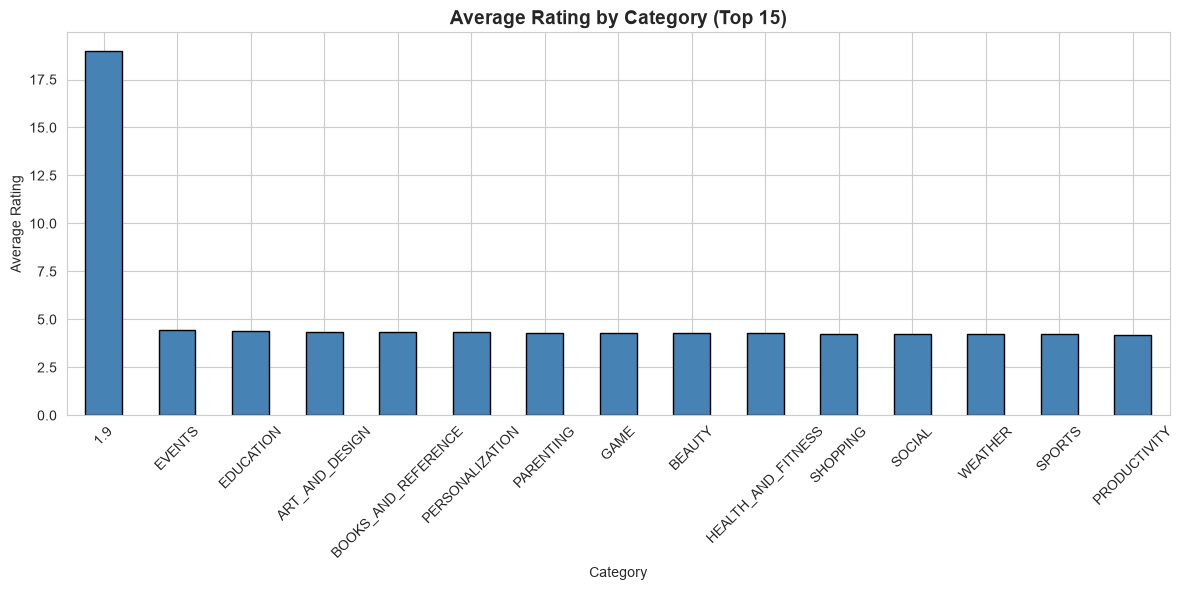

In [26]:
# 2. Average Rating by Category 

avg_rating = (
    apps.groupby("Category")["Rating"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)
plt.figure(figsize=(12, 6))
avg_rating.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Average Rating by Category (Top 15)", fontsize=14, fontweight="bold")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

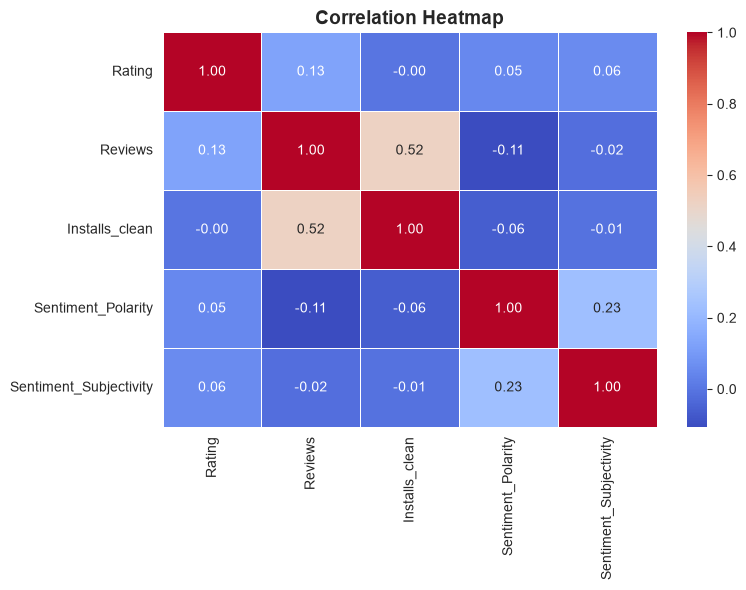

In [27]:
#3. CORRELATION HEATMAP

plt.figure(figsize=(8, 6))
corr_cols = ["Rating", "Reviews", "Installs_clean", "Sentiment_Polarity", "Sentiment_Subjectivity"]
sns.heatmap(
    merged[corr_cols].corr(),
    annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5
)
plt.title("Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [28]:
# KEY INSIGHTS SUMMARY

print("\n" + "=" * 70)
print("🔑 KEY INSIGHTS")
print("=" * 70)
print(f"Total Apps               : {apps.shape[0]}")
print(f"Total Reviews            : {reviews_clean.shape[0]}")
print(f"Total Categories         : {apps['Category'].nunique()}")
print(f"Free Apps                : {(apps['Type'] == 'Free').sum()}")
print(f"Paid Apps                : {(apps['Type'] == 'Paid').sum()}")
print(f"Average Rating           : {apps['Rating'].mean():.2f}")
print(f"Most Common Category     : {apps['Category'].mode()[0]}")
print(f"Top Installed Category   : {top_installs.index[0]}")
print(f"Positive Reviews         : {(reviews_clean['Sentiment'] == 'Positive').sum()}")
print(f"Negative Reviews         : {(reviews_clean['Sentiment'] == 'Negative').sum()}")
print(f"Neutral Reviews          : {(reviews_clean['Sentiment'] == 'Neutral').sum()}")

print("\n✅ EDA COMPLETED SUCCESSFULLY!")
print("=" * 70)


🔑 KEY INSIGHTS
Total Apps               : 10841
Total Reviews            : 37427
Total Categories         : 34
Free Apps                : 10039
Paid Apps                : 800
Average Rating           : 4.19
Most Common Category     : FAMILY
Top Installed Category   : GAME
Positive Reviews         : 23998
Negative Reviews         : 8271
Neutral Reviews          : 5158

✅ EDA COMPLETED SUCCESSFULLY!
